In [1]:
# Import Libraries

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load Titanic Dataset

titanic = sns.load_dataset('titanic')

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


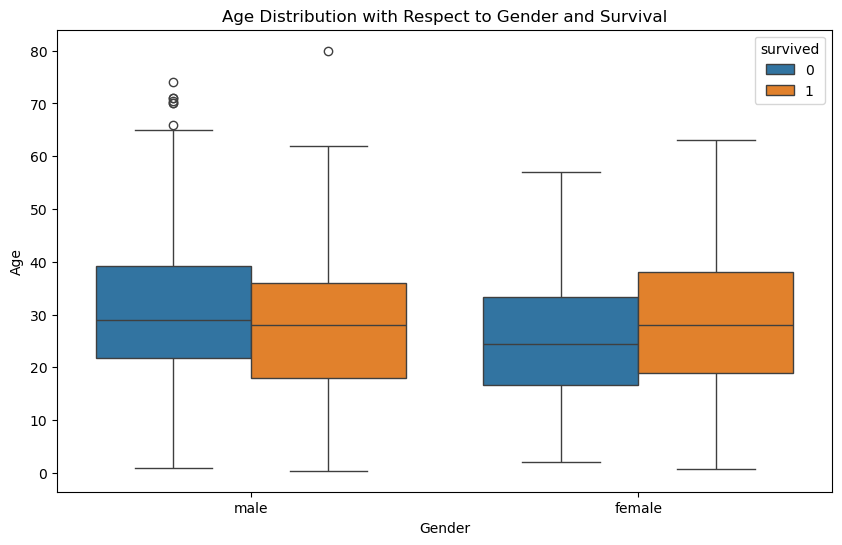

In [5]:
# Boxplot for Age Distribution

plt.figure(figsize=(10,6))

sns.boxplot(x='sex', y='age', hue='survived', data=titanic)

plt.title("Age Distribution with Respect to Gender and Survival")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

<Axes: xlabel='sex', ylabel='age'>

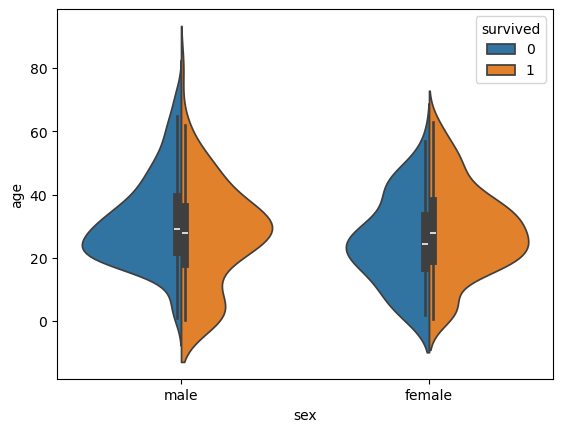

In [7]:
sns.violinplot(x = "sex", y = "age", data = titanic, hue = "survived", split = True)

<Axes: xlabel='sex', ylabel='age'>

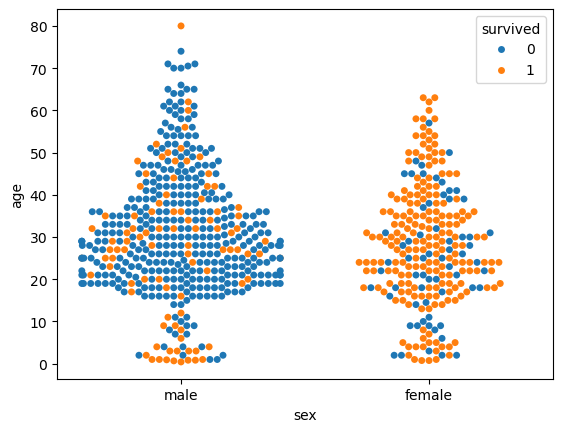

In [9]:
sns.swarmplot(x = "sex", y = "age", data = titanic, hue = "survived")

In [11]:
def find_outliers(group):
    Q1 = group["age"].quantile(0.25)
    Q3 = group["age"].quantile(0.75)

    IQR = Q3 - Q1

    lowerBound = Q1 - 1.5 * IQR 
    upperBound = Q3 + 1.5 * IQR

    return group[(group["age"] < lowerBound) | (group["age"] > upperBound)]


In [13]:
outliers = titanic.groupby(["sex","alive"], group_keys=False).apply(find_outliers)

C:\Users\Prajwal\AppData\Local\Temp\ipykernel_26348\3095786132.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers = titanic.groupby(["sex","alive"], group_keys=False).apply(find_outliers)


In [15]:
outliers

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
493,0,1,male,71.0,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True
672,0,2,male,70.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
745,0,1,male,70.0,1,1,71.0000,S,First,man,True,B,Southampton,no,False
851,0,3,male,74.0,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True
630,1,1,male,80.0,0,0,30.0000,S,First,man,True,A,Southampton,yes,True
